# 1. Configuración inicial y funciones base
Importamos las librerías necesarias y definimos las funciones para calcular y graficar el Payoff (código de clase).

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def payoff_estrategia(S_range, legs):
    """Calcula el P&L neto de una estrategia con cualquier número de legs."""
    total = np.zeros(len(S_range))
    for leg in legs:
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - leg['K'], 0)
        else:
            payoff = np.maximum(leg['K'] - S_range, 0)
        pnl = leg['posicion'] * (payoff - leg['prima'])
        total += pnl
    return total

def graficar_estrategia(S_range, pnl, titulo, K_lines=None):
    """Grafica el P&L de una estrategia con formato estándar."""
    plt.figure(figsize=(9, 5))
    plt.plot(S_range, pnl, color='steelblue', linewidth=2)
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    if K_lines:
        for k, label in K_lines:
            plt.axvline(k, color='gray', linewidth=0.8, linestyle=':', label=label)
    plt.fill_between(S_range, pnl, 0, where=(pnl > 0), alpha=0.15, color='green', label='Ganancia')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0), alpha=0.15, color='red', label='Pérdida')
    plt.xlabel('Precio al vencimiento $S_T$')
    plt.ylabel('P&L ($)')
    plt.title(titulo)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 2. Extracción dinámica de datos con yfinance
Descargamos los precios de las opciones de SPY para el vencimiento 2026-04-17 y calculamos el precio *mid*.

In [2]:
# Descargar datos de SPY
spy = yf.Ticker("SPY")
S0 = spy.history(period="1d")['Close'].iloc[-1]
print(f"Precio Spot Actual (S0): ${S0:.2f}")

# Extraer cadena de opciones para el vencimiento solicitado
vencimiento = '2026-04-17'
opts = spy.option_chain(vencimiento)

calls = opts.calls
puts = opts.puts

# Calcular precio mid
calls['mid'] = (calls['bid'] + calls['ask']) / 2
puts['mid'] = (puts['bid'] + puts['ask']) / 2

# Rango de precios para graficar (± 20% del precio Spot)
S_range = np.linspace(S0 * 0.8, S0 * 1.2, 500)

# Función auxiliar para obtener la prima del strike más cercano
def get_prima(tipo, K):
    df = calls if tipo == 'call' else puts
    strike_cercano = df.iloc[(df['strike'] - K).abs().argsort()[:1]]['strike'].values[0]
    prima = df[df['strike'] == strike_cercano]['mid'].values[0]
    return prima, strike_cercano

# Determinar el Strike ATM (At-The-Money)
K_atm = calls.iloc[(calls['strike'] - S0).abs().argsort()[:1]]['strike'].values[0]

Precio Spot Actual (S0): $676.01


## 3. Long Straddle
Compra de una Call y una Put al mismo Strike ATM.

--- LONG STRADDLE ---
Costo / Prima neta : $14.61
Ganancia máxima    : Ilimitada
Pérdida máxima     : $-14.61  (si ST = 676.0)
Break-even sup.    : $690.61
Break-even inf.    : $661.39


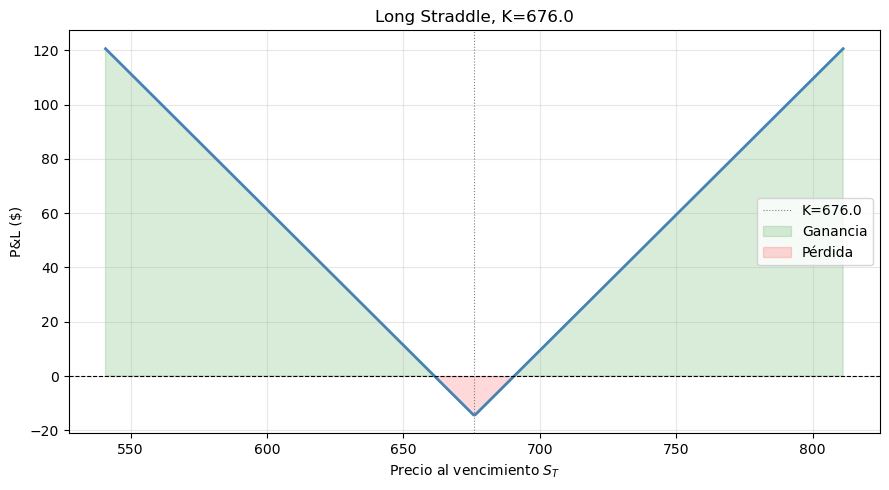

In [3]:
C_atm, K_atm = get_prima('call', K_atm)
P_atm, K_atm = get_prima('put', K_atm)

legs_straddle = [
    {'tipo': 'call', 'K': K_atm, 'prima': C_atm, 'posicion': +1},
    {'tipo': 'put',  'K': K_atm, 'prima': P_atm, 'posicion': +1},
]
pnl_straddle = payoff_estrategia(S_range, legs_straddle)
costo_straddle = C_atm + P_atm

print("--- LONG STRADDLE ---")
print(f"Costo / Prima neta : ${costo_straddle:.2f}")
print(f"Ganancia máxima    : Ilimitada")
print(f"Pérdida máxima     : ${-costo_straddle:.2f}  (si ST = {K_atm})")
print(f"Break-even sup.    : ${K_atm + costo_straddle:.2f}")
print(f"Break-even inf.    : ${K_atm - costo_straddle:.2f}")

graficar_estrategia(S_range, pnl_straddle, f'Long Straddle, K={K_atm}', K_lines=[(K_atm, f'K={K_atm}')])

## 4. Long Strangle
Compra de una Put OTM y una Call OTM.

--- LONG STRANGLE ---
Strikes usados     : Put K1=642.0, Call K2=710.0
Costo / Prima neta : $1.16
Ganancia máxima    : Ilimitada
Pérdida máxima     : $-1.16  (si 642.0 <= ST <= 710.0)
Break-even sup.    : $711.16
Break-even inf.    : $640.84


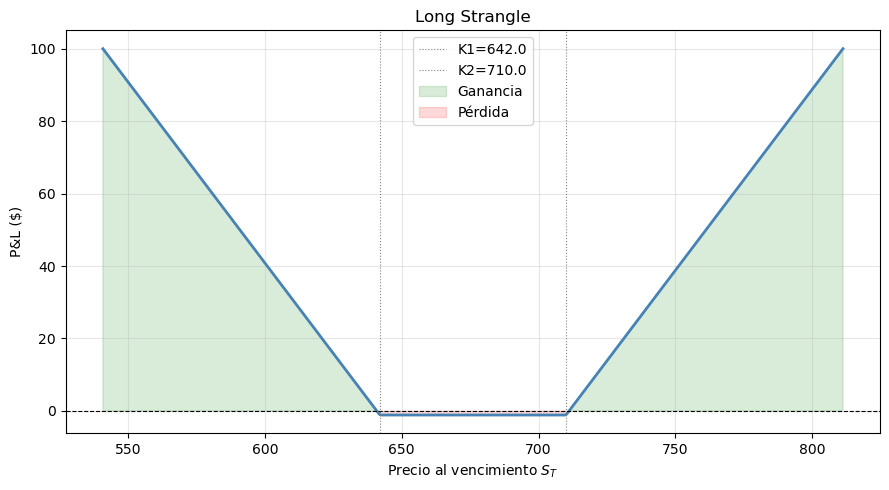

In [4]:
# Definimos strikes un ±5% OTM
P_otm, K1_strangle = get_prima('put', S0 * 0.95)
C_otm, K2_strangle = get_prima('call', S0 * 1.05)

legs_strangle = [
    {'tipo': 'put',  'K': K1_strangle, 'prima': P_otm, 'posicion': +1},
    {'tipo': 'call', 'K': K2_strangle, 'prima': C_otm, 'posicion': +1},
]
pnl_strangle = payoff_estrategia(S_range, legs_strangle)
costo_strangle = P_otm + C_otm

print("--- LONG STRANGLE ---")
print(f"Strikes usados     : Put K1={K1_strangle}, Call K2={K2_strangle}")
print(f"Costo / Prima neta : ${costo_strangle:.2f}")
print(f"Ganancia máxima    : Ilimitada")
print(f"Pérdida máxima     : ${-costo_strangle:.2f}  (si {K1_strangle} <= ST <= {K2_strangle})")
print(f"Break-even sup.    : ${K2_strangle + costo_strangle:.2f}")
print(f"Break-even inf.    : ${K1_strangle - costo_strangle:.2f}")

graficar_estrategia(S_range, pnl_strangle, f'Long Strangle', K_lines=[(K1_strangle, f'K1={K1_strangle}'), (K2_strangle, f'K2={K2_strangle}')])

## 5. Bull Call Spread
Comprar una Call ITM (strike menor) y Vender una Call OTM (strike mayor).

--- BULL CALL SPREAD ---
Strikes usados     : Long Call K1=642.0, Short Call K2=710.0
Costo / Prima neta : $35.14
Ganancia máxima    : $32.86  (si ST >= 710.0)
Pérdida máxima     : $-35.14  (si ST <= 642.0)
Break-even         : $677.14


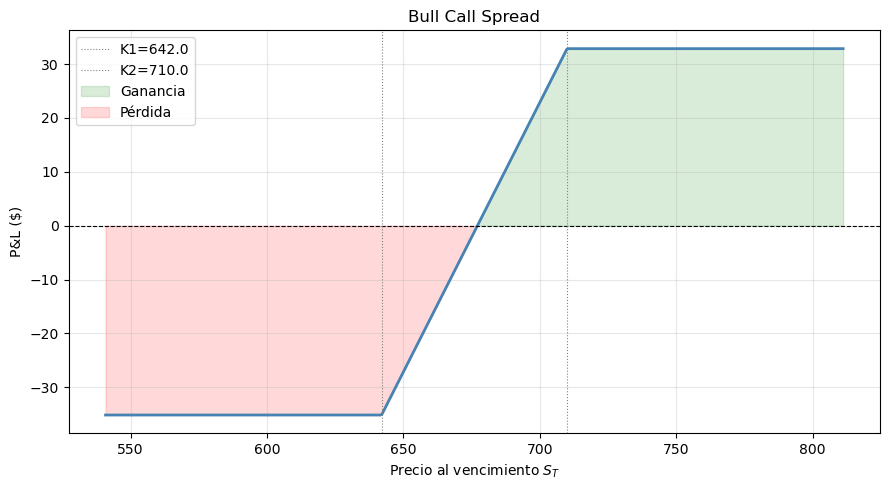

In [5]:
C1_bull, K1_bull = get_prima('call', S0 * 0.95) # ITM
C2_bull, K2_bull = get_prima('call', S0 * 1.05) # OTM

legs_bull = [
    {'tipo': 'call', 'K': K1_bull, 'prima': C1_bull, 'posicion': +1},
    {'tipo': 'call', 'K': K2_bull, 'prima': C2_bull, 'posicion': -1},
]
pnl_bull = payoff_estrategia(S_range, legs_bull)
costo_bull = C1_bull - C2_bull

print("--- BULL CALL SPREAD ---")
print(f"Strikes usados     : Long Call K1={K1_bull}, Short Call K2={K2_bull}")
print(f"Costo / Prima neta : ${costo_bull:.2f}")
print(f"Ganancia máxima    : ${(K2_bull - K1_bull) - costo_bull:.2f}  (si ST >= {K2_bull})")
print(f"Pérdida máxima     : ${-costo_bull:.2f}  (si ST <= {K1_bull})")
print(f"Break-even         : ${K1_bull + costo_bull:.2f}")

graficar_estrategia(S_range, pnl_bull, f'Bull Call Spread', K_lines=[(K1_bull, f'K1={K1_bull}'), (K2_bull, f'K2={K2_bull}')])

## 6. Bear Put Spread
Comprar una Put ITM (strike mayor) y Vender una Put OTM (strike menor).

--- BEAR PUT SPREAD ---
Strikes usados     : Long Put K1=710.0, Short Put K2=642.0
Costo / Prima neta : $33.44
Ganancia máxima    : $34.56  (si ST <= 642.0)
Pérdida máxima     : $-33.44  (si ST >= 710.0)
Break-even         : $676.56


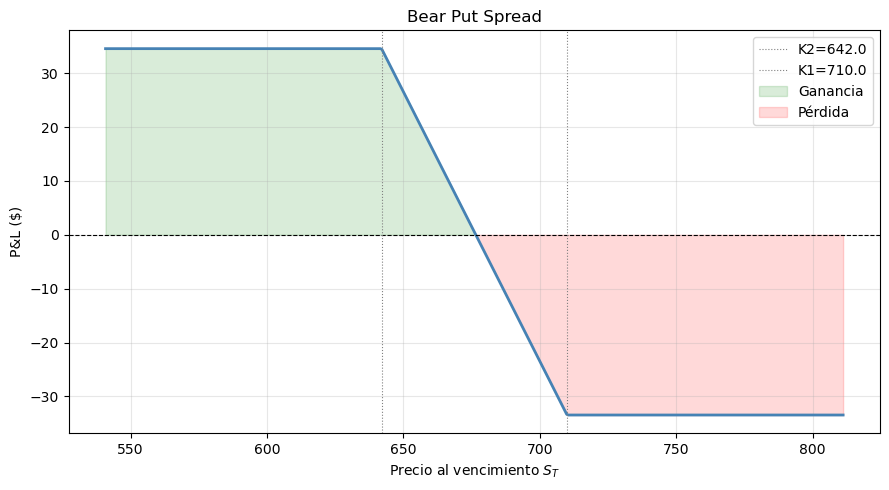

In [6]:
P1_bear, K1_bear = get_prima('put', S0 * 1.05) # ITM
P2_bear, K2_bear = get_prima('put', S0 * 0.95) # OTM

legs_bear = [
    {'tipo': 'put', 'K': K1_bear, 'prima': P1_bear, 'posicion': +1},
    {'tipo': 'put', 'K': K2_bear, 'prima': P2_bear, 'posicion': -1},
]
pnl_bear = payoff_estrategia(S_range, legs_bear)
costo_bear = P1_bear - P2_bear

print("--- BEAR PUT SPREAD ---")
print(f"Strikes usados     : Long Put K1={K1_bear}, Short Put K2={K2_bear}")
print(f"Costo / Prima neta : ${costo_bear:.2f}")
print(f"Ganancia máxima    : ${(K1_bear - K2_bear) - costo_bear:.2f}  (si ST <= {K2_bear})")
print(f"Pérdida máxima     : ${-costo_bear:.2f}  (si ST >= {K1_bear})")
print(f"Break-even         : ${K1_bear - costo_bear:.2f}")

graficar_estrategia(S_range, pnl_bear, f'Bear Put Spread', K_lines=[(K2_bear, f'K2={K2_bear}'), (K1_bear, f'K1={K1_bear}')])

## 7. Tabla Resumen Consolidada
Consolidamos las métricas extraídas en un DataFrame.

In [7]:
resumen = pd.DataFrame({
    'Estrategia': ['Long Straddle', 'Long Strangle', 'Bull Call Spread', 'Bear Put Spread'],
    'Costo / Prima Neta': [costo_straddle, costo_strangle, costo_bull, costo_bear],
    'Ganancia Máxima': ['Ilimitada', 'Ilimitada', (K2_bull - K1_bull) - costo_bull, (K1_bear - K2_bear) - costo_bear],
    'Pérdida Máxima': [-costo_straddle, -costo_strangle, -costo_bull, -costo_bear],
    'Break-Even(s)': [
        f"${K_atm - costo_straddle:.2f} y ${K_atm + costo_straddle:.2f}",
        f"${K1_strangle - costo_strangle:.2f} y ${K2_strangle + costo_strangle:.2f}",
        f"${K1_bull + costo_bull:.2f}",
        f"${K1_bear - costo_bear:.2f}"
    ]
})

# Formatear números a 2 decimales en el dataframe para mejor visualización
resumen['Costo / Prima Neta'] = resumen['Costo / Prima Neta'].map(lambda x: f"${x:.2f}")
resumen['Pérdida Máxima'] = resumen['Pérdida Máxima'].map(lambda x: f"${x:.2f}")
resumen['Ganancia Máxima'] = resumen['Ganancia Máxima'].apply(lambda x: f"${x:.2f}" if isinstance(x, float) else x)

resumen.set_index('Estrategia', inplace=True)
display(resumen)

,Costo / Prima Neta,Ganancia Máxima,Pérdida Máxima,Break-Even(s)
Estrategia,,,,
Long Straddle,$14.61,Ilimitada,$-14.61,$661.39 y $690.61
Long Strangle,$1.16,Ilimitada,$-1.16,$640.84 y $711.16
Bull Call Spread,$35.14,$32.86,$-35.14,$677.14
Bear Put Spread,$33.44,$34.56,$-33.44,$676.56


- Con el S0 actual, ¿cuál de las cuatro estrategias está más cerca de su zona de máxima pérdida? ¿Qué te dice eso sobre la visión de mercado que expresa?

Para todas, el S0 está bastante centrado entre máxima pérdida y máxima ganancia, parece que el precio está estable por ahora

- Compara el costo total del long straddle vs. el long strangle que construiste. ¿Cuánto más barato es el strangle? ¿Cuánto más tiene que moverse SPY para que el strangle sea rentable comparado con el straddle?

El Long Strangle pareciera obviamente mejor que el straddle dada la pérdida máxima pero, El rango de Break-Even es mucho más amplio. El SPY tendría que moverse mayor a $711 o menos a $640 para empezar a generar ganancias

- Un long straddle gana si el mercado se mueve mucho. ¿Qué pasa si compras el straddle justo después de que la IV ya subió por anticipación de un evento (por ejemplo, el día antes de earnings o de una decisión de la Fed)? ¿Sigue siendo una buena estrategia? Justifica.

Nelpastel. No es buena estrategia. Lo bueno hubiera sido comprarlo justo antes, ya que la alza del IV hace que la opcion se haga más cara y que el precio del subyacente se mueva volatilmente. Lo bueno sería comprar antes de que la prima esté cara y ganar cuando el precio se mueva.

- El bull call spread limita la ganancia máxima comparado con un call simple. ¿Por qué alguien aceptaría ese límite voluntariamente? Da al menos dos razones.

Comprar un call simple da un precio inicial más caro. Al tener un short put reduces el precio inicial pq se te pagará la prima, el precio de lograr eso es que se te limita la ganancia.

- Si tienes un bull spread abierto y SPY supera K2 antes del vencimiento, ¿tiene sentido cerrar la posición o esperar al vencimiento? ¿Qué factores considerarías para decidir?

Sí tiene sentido cerrar la posición. Como bien podrías continuar ganando, el riesgo que asumes es equivalente al de seguir perdiendo, sin embargo, como la ganancia esta topada, el riesgo de pérdida cuesta más que la ganancia. Más vale take profit que arriesgarte, ya que el profit solo puede crecer poquito más.

- ¿Cómo afecta un aumento de IV a un bull spread comparado con un long straddle? ¿Cuál de las dos posiciones es más sensible a cambios en volatilidad implícita y por qué?

El aumento de IV afecta directa y positivamente al long straddle pq eso significa que St es más probable a moverse (moverse en general), eso genera ganancias para long straddle. Al bull spread casi ni le afecta pq tiene posición tanto long como short, que al final cancelan

- En términos de griegas (delta, gamma, vega, theta), ¿cuál es la diferencia principal entre comprar un call simple y comprar un bull call spread? ¿Qué griega cambia más drásticamente entre las dos estructuras?

Theta y vega son la exposición al tiempo y a la volatilidad. Esas dos griegas (y otras) se encuentran en un call simple. Al hacer bull call spread se cancelan ambas. La volatilidad nos afecta poco o nada ya que estamos cubiertos con posiciones short y long (Lo vimos en la pregunta pasada). Nos cubrimos del desgaste del tiempo ya que también es donde se encuentra la volatilidad.